In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('drive/MyDrive/E-commerce_cleaned_D.csv')  # Changed the file path

print(df.head(5))

   Customer ID        Purchase Date Product Category  Product Price  Quantity  \
0        46251  2020-09-08 09:38:00      Electronics             12         3   
1        46251  2022-03-05 12:56:00             Home            468         4   
2        46251  2022-05-23 18:18:00             Home            288         2   
3        46251  2020-11-12 13:13:00         Clothing            196         1   
4        13593  2020-11-27 17:55:00             Home            449         1   

   Total Purchase Amount Payment Method  Customer Age  Returns  \
0                    740    Credit Card            37      0.0   
1                   2739         PayPal            37      0.0   
2                   3196         PayPal            37      0.0   
3                   3509         PayPal            37      0.0   
4                   3452    Credit Card            49      0.0   

         Customer Name  Gender  Churn  
0  Christine Hernandez    Male      0  
1  Christine Hernandez    Male      

Customer Behavior Analysis Plan
Here’s how we can break it down:

Step	What We'll Do	Why It Matters

1	Basic Metrics (total spend, number of purchases)	Who are your most valuable customers

2	RFM Analysis (Recency, Frequency, Monetary)	Group customers by loyalty/engagement

3	Customer Segmentation (Optional next step)	Personalized marketing strategies

Step 1: Basic Customer Metrics

In [6]:
import pandas as pd

# Load data

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Group by customer
customer_behavior = df.groupby('Customer ID').agg({
    'Purchase Date': ['min', 'max', 'nunique'],
    'Total Purchase Amount': 'sum'
})

customer_behavior.columns = ['First Purchase', 'Last Purchase', 'Number of Purchases', 'Total Spend']
customer_behavior['Customer Lifetime (days)'] = (customer_behavior['Last Purchase'] - customer_behavior['First Purchase']).dt.days

customer_behavior.sort_values('Total Spend', ascending=False).head(10)


,First Purchase,Last Purchase,Number of Purchases,Total Spend,Customer Lifetime (days)
Customer ID,,,,,
36437,2020-01-06 13:15:00,2023-08-25 12:36:00,17,55339,1326
39817,2020-02-27 14:07:00,2023-03-04 15:37:00,17,51718,1101
26977,2020-01-24 17:56:00,2023-09-01 08:13:00,14,48497,1315
5844,2020-07-04 13:47:00,2023-08-15 06:17:00,12,46541,1136
3576,2020-05-10 03:01:00,2023-01-15 22:33:00,14,46518,980
13802,2020-02-22 07:09:00,2023-08-30 07:16:00,13,46464,1285
809,2020-02-03 21:12:00,2023-08-25 20:50:00,15,45738,1298
47087,2020-01-08 22:36:00,2023-06-02 23:16:00,17,45700,1241
14400,2020-04-24 00:18:00,2023-06-24 07:33:00,15,45334,1156


Step 2: RFM Analysis (Recency, Frequency, Monetary)

Recency (R): How recently did the customer purchase?

Frequency (F): How often do they purchase?

Monetary (M): How much money do they spend?

In [7]:
import datetime as dt

snapshot_date = df['Purchase Date'].max() + dt.timedelta(days=1)

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.describe()


,Recency,Frequency,Monetary
count,49673.000000,49673.000000,49673.000000
mean,261.425563,5.032915,13716.559962
std,246.023909,2.206427,6840.208557
min,1.000000,1.000000,110.000000
25%,78.000000,3.000000,8719.000000
50%,185.000000,5.000000,13026.000000
75%,369.000000,6.000000,17966.000000
max,1353.000000,17.000000,55339.000000


Step 3 (Optional Bonus): Visualize RFM Segments

You can assign RFM scores and create customer segments like:

RFM Profile	                        
Low R, High F, High M                    
High R, Low F, Low M                   
Low R, High F, Low M                    
High R, Low F, High M      

Customer Type

Loyal Customer

At Risk

Potential Loyalist

Big Spenders

Step 1: Visualize RFM Segments (Scatter Plot)

First, visualize customers based on Recency vs Frequency vs Monetary.

1	Visualize RFM Segments	Understand customer types

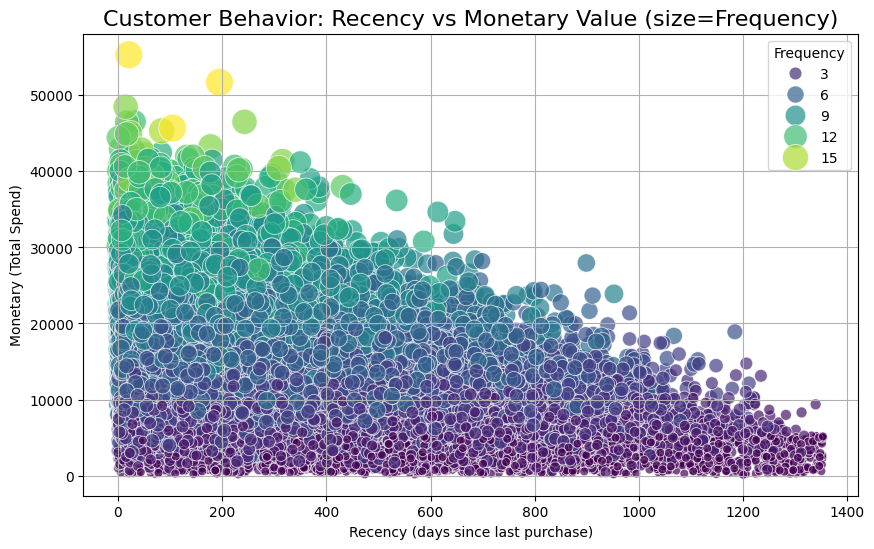

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you already have the 'rfm' table from earlier
# Let's visualize

plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', size='Frequency', hue='Frequency', palette='viridis', alpha=0.7, sizes=(40, 400))

plt.title('Customer Behavior: Recency vs Monetary Value (size=Frequency)', fontsize=16)
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.legend(title='Frequency')
plt.grid(True)
plt.show()


Interpretation:

Customers bottom-right (low Recency, high Monetary) = 💎 Best Customers

Customers top-left (high Recency, low Monetary) = 💤 At-Risk

Step 2: KMeans Clustering
Automatically group customers into behavior types using clustering!

2	Cluster Customers (KMeans)	Group customers automatically

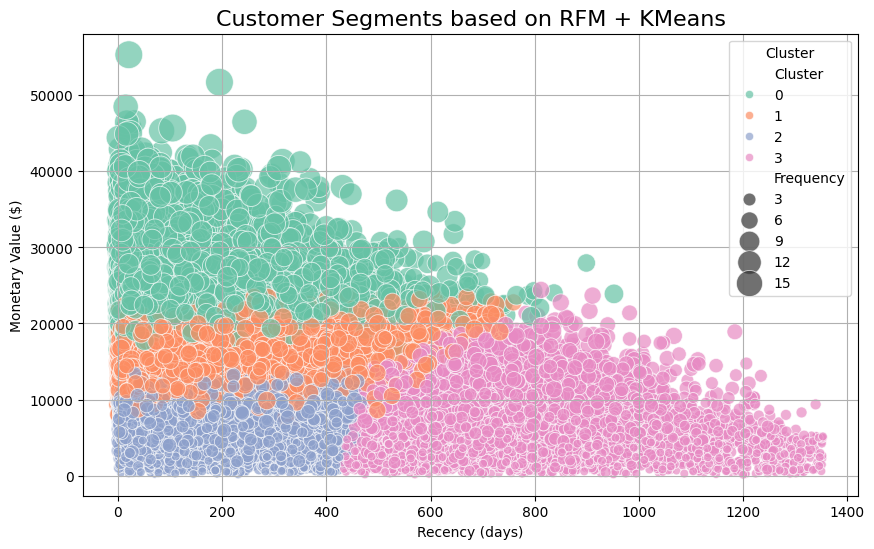

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Normalize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Visualize clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='Set2', size='Frequency', sizes=(40, 400), alpha=0.7)

plt.title('Customer Segments based on RFM + KMeans', fontsize=16)
plt.xlabel('Recency (days)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


Interpretation:

Each color is a different customer segment — e.g.,

Cluster 0 = VIP Customers

Cluster 1 = At Risk

Cluster 2 = Potential Loyalists

Step 3: Predict Churn Risk

3, Predict churn risks	Find customers likely to leave

What’s the idea?

We’ll build a model that predicts if a customer is likely to churn (stop purchasing).

👉 How will we label churn?

Customers who haven't purchased in a long time (high Recency) = likely churners

We'll define:

If Recency > median Recency → Churn = 1

Else → Churn = 0

Step 3.1: Create "Churn" Label

In [10]:
# Define churn: customers with higher than median recency are "likely to churn"
rfm['Churn'] = (rfm['Recency'] > rfm['Recency'].median()).astype(int)

rfm[['Recency', 'Frequency', 'Monetary', 'Cluster', 'Churn']].head()


,Recency,Frequency,Monetary,Cluster,Churn
Customer ID,,,,,
1,58,1,3491,2,0
2,299,3,7988,2,1
3,89,8,22587,0,0
4,127,4,8715,2,0
5,171,8,12524,1,0


Now we have a "Churn" column:

1 = Likely to churn

0 = Active customer

Step 3.2: Build Prediction Model

Let's build a simple Logistic Regression model:

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Features and Target
X = rfm[['Recency', 'Frequency', 'Monetary', 'Cluster']]
y = rfm['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7549
           1       0.97      0.99      0.98      7353

    accuracy                           0.98     14902
   macro avg       0.98      0.98      0.98     14902
weighted avg       0.98      0.98      0.98     14902



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This gives you:

Accuracy

Precision (important if you care about false alarms)

Recall (important if you care about not missing churners)

Step 3.3 (Bonus): See Churn Prediction Importance

<Axes: title={'center': 'Feature Importance for Churn Prediction'}>

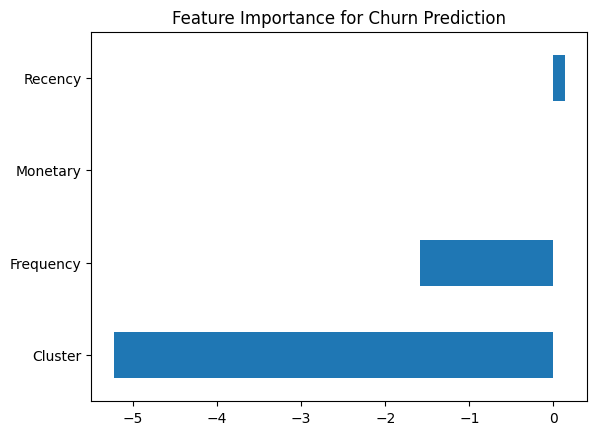

In [13]:
# Feature Importance
importance = pd.Series(model.coef_[0], index=X.columns).sort_values()

importance.plot(kind='barh', title='Feature Importance for Churn Prediction')


Step 4: Predict Individual Churn Probabilities

👉 Instead of just "Churn or Not" (0/1),
let’s get how likely each customer is to churn.

🛠️ Step 4.1: Predict Probabilities



In [14]:
# Predict churn probabilities
y_probs = model.predict_proba(X_test)[:, 1]  # Get probability of churn (class=1)

# Attach to the test set
results = X_test.copy()
results['Actual_Churn'] = y_test
results['Churn_Probability'] = y_probs

# Show top customers with highest risk
results_sorted = results.sort_values('Churn_Probability', ascending=False)
results_sorted.head(10)


,Recency,Frequency,Monetary,Cluster,Actual_Churn,Churn_Probability
Customer ID,,,,,,
6594,504,3,8100,3,1,1.0
44495,663,3,9234,3,1,1.0
11684,536,4,16197,3,1,1.0
32492,544,5,8651,3,1,1.0
11022,512,4,15288,3,1,1.0
49221,1154,1,2293,3,1,1.0
32937,649,2,2278,3,1,1.0
30007,542,3,8307,3,1,1.0
44527,577,4,8942,3,1,1.0


Step 4.2: Visualize Customer Churn Risk

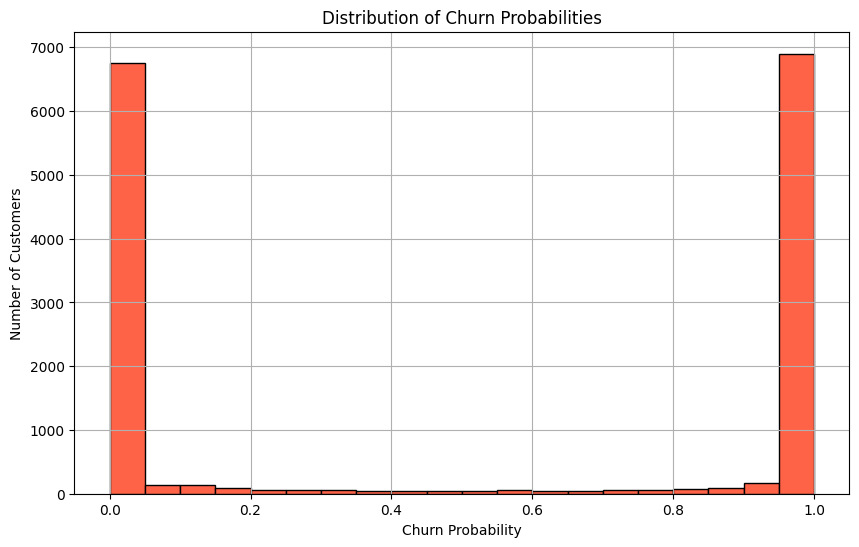

In [15]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(10, 6))
plt.hist(results['Churn_Probability'], bins=20, color='tomato', edgecolor='black')
plt.title('Distribution of Churn Probabilities')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()


Interpretation:

A lot of customers have low risk (left side).

Some have high risk (right side) → 🛑 You should focus retention strategies on them!

5, Tune the model (Logistic Regression → Random Forest / XGBoost for better results)

Step5.1	What we do	Goal
Train a Random Forest	Stronger model, less sensitive

Step 1: Random Forest

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report

print("Random Forest Performance:")
print(classification_report(y_test, rf_preds))


Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7549
           1       1.00      1.00      1.00      7353

    accuracy                           1.00     14902
   macro avg       1.00      1.00      1.00     14902
weighted avg       1.00      1.00      1.00     14902



Step 2: XGBoost

In [17]:
from xgboost import XGBClassifier

# XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)

# Evaluate
print("XGBoost Performance:")
print(classification_report(y_test, xgb_preds))


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:30:11] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7549
           1       1.00      1.00      1.00      7353

    accuracy                           1.00     14902
   macro avg       1.00      1.00      1.00     14902
weighted avg       1.00      1.00      1.00     14902



Step 3: Compare Models Side-by-Side



In [18]:
from sklearn.metrics import accuracy_score

# Accuracy scores
logistic_acc = accuracy_score(y_test, y_pred)
rf_acc = accuracy_score(y_test, rf_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"Logistic Regression Accuracy: {logistic_acc:.2f}")
print(f"Random Forest Accuracy: {rf_acc:.2f}")
print(f"XGBoost Accuracy: {xgb_acc:.2f}")


Logistic Regression Accuracy: 0.98
Random Forest Accuracy: 1.00
XGBoost Accuracy: 1.00


Feature Importance (for Random Forest / XGBoost)

<Axes: title={'center': 'Random Forest Feature Importance'}>

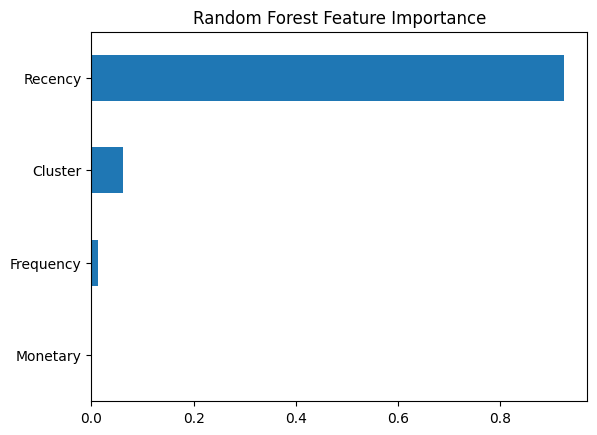

In [19]:
# Random Forest feature importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='Random Forest Feature Importance')


<Axes: title={'center': 'XGBoost Feature Importance'}>

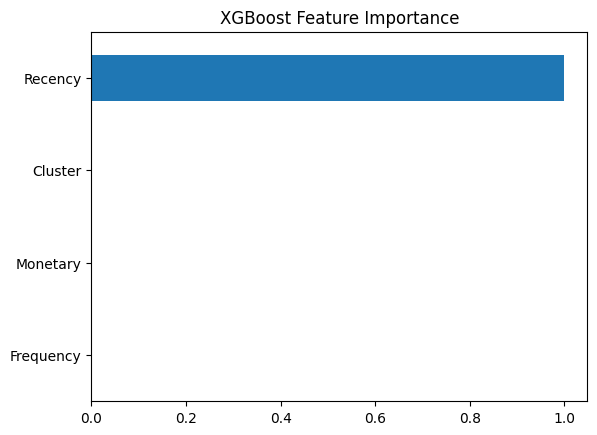

In [20]:
# XGBoost feature importance
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', title='XGBoost Feature Importance')


We’ll hyperparameter tune using GridSearchCV.

👉 This means trying different settings to find the absolute best model automatically.

Step 1: Tune Random Forest



In [21]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
rf_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

# Grid search
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid,
    cv=3,  # 3-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

# Best Random Forest
best_rf = rf_search.best_estimator_
print("Best Random Forest:", rf_search.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best Random Forest: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


Step 2: Tune XGBoost



In [22]:
# Define hyperparameter grid
xgb_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
}

# Grid search
xgb_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    xgb_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

# Best XGBoost
best_xgb = xgb_search.best_estimator_
print("Best XGBoost:", xgb_search.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [10:32:18] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


Step 3: Compare Tuned Models

In [23]:
# Predictions
best_rf_preds = best_rf.predict(X_test)
best_xgb_preds = best_xgb.predict(X_test)

# Evaluation
from sklearn.metrics import classification_report

print("Tuned Random Forest Performance:")
print(classification_report(y_test, best_rf_preds))

print("Tuned XGBoost Performance:")
print(classification_report(y_test, best_xgb_preds))



Tuned Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7549
           1       1.00      1.00      1.00      7353

    accuracy                           1.00     14902
   macro avg       1.00      1.00      1.00     14902
weighted avg       1.00      1.00      1.00     14902

Tuned XGBoost Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7549
           1       1.00      1.00      1.00      7353

    accuracy                           1.00     14902
   macro avg       1.00      1.00      1.00     14902
weighted avg       1.00      1.00      1.00     14902



Make a Churn Risk Dashboard 📊

Step 1: Get Risk Scores

We predict probability of churn for each customer:

In [24]:
# Predict probabilities with best model (e.g., best_xgb)
risk_scores = best_xgb.predict_proba(X_test)[:, 1]  # Probability of churn

# Create a DataFrame
risk_df = pd.DataFrame({
    'CustomerID': X_test.index,   # or your customer identifier
    'Churn_Probability': risk_scores
})

# Sort by highest risk
risk_df = risk_df.sort_values(by='Churn_Probability', ascending=False)

risk_df.head(10)  # Top 10 risky customers


,CustomerID,Churn_Probability
14900,6594,0.817264
0,12031,0.817264
1,43457,0.817264
2,5973,0.817264
3,18302,0.817264
14883,22441,0.817264
14881,24088,0.817264
14880,44495,0.817264
14875,11684,0.817264
14872,32492,0.817264


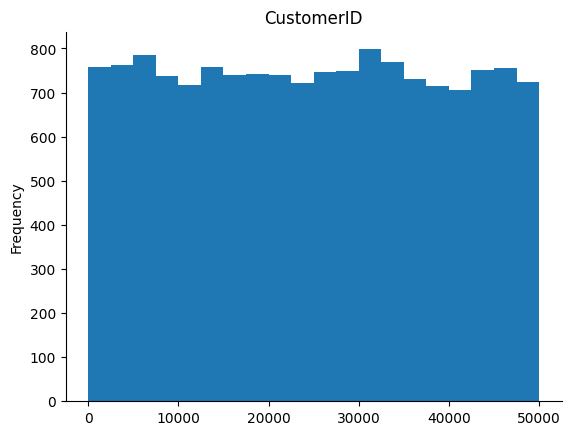

In [ ]:
# @title CustomerID

from matplotlib import pyplot as plt
risk_df['CustomerID'].plot(kind='hist', bins=20, title='CustomerID')
plt.gca().spines[['top', 'right',]].set_visible(False)

Step 2: Plot Risk Distribution

See how risky your whole customer base is.

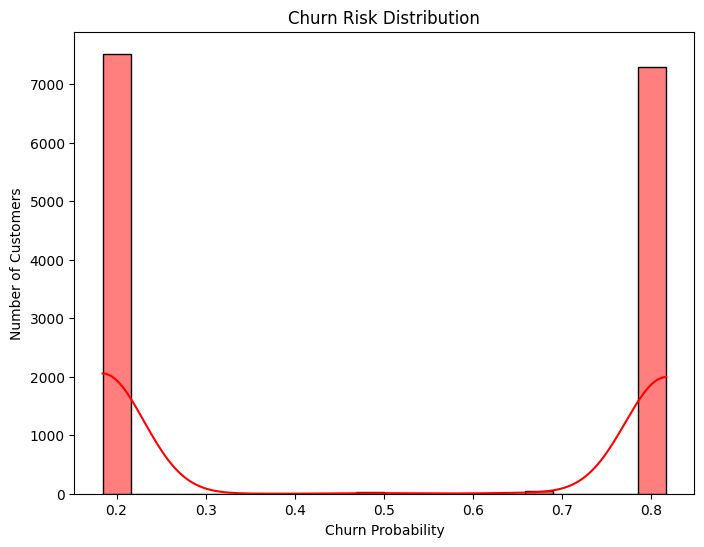

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.histplot(risk_df['Churn_Probability'], bins=20, kde=True, color='red')
plt.title('Churn Risk Distribution')
plt.xlabel('Churn Probability')
plt.ylabel('Number of Customers')
plt.show()


Step 3: Show Top Risk Customers

Simple DataFrame of top customers you need to save ASAP:

In [27]:
top_risk_customers = risk_df[risk_df['Churn_Probability'] > 0.7]  # threshold can change
top_risk_customers.head(10)


,CustomerID,Churn_Probability
14900,6594,0.817264
0,12031,0.817264
1,43457,0.817264
2,5973,0.817264
3,18302,0.817264
14883,22441,0.817264
14881,24088,0.817264
14880,44495,0.817264
14875,11684,0.817264
14872,32492,0.817264


Step 4: (Bonus) Action Plan Suggestion

In [28]:
def retention_action(prob):
    if prob > 0.9:
        return 'Urgent: Personal Call'
    elif prob > 0.7:
        return 'Offer Discount or Loyalty Bonus'
    elif prob > 0.5:
        return 'Send Special Email Offer'
    else:
        return 'Normal Follow-up'

risk_df['Action_Plan'] = risk_df['Churn_Probability'].apply(retention_action)

risk_df.head(10)


,CustomerID,Churn_Probability,Action_Plan
14900,6594,0.817264,Offer Discount or Loyalty Bonus
0,12031,0.817264,Offer Discount or Loyalty Bonus
1,43457,0.817264,Offer Discount or Loyalty Bonus
2,5973,0.817264,Offer Discount or Loyalty Bonus
3,18302,0.817264,Offer Discount or Loyalty Bonus
14883,22441,0.817264,Offer Discount or Loyalty Bonus
14881,24088,0.817264,Offer Discount or Loyalty Bonus
14880,44495,0.817264,Offer Discount or Loyalty Bonus
14875,11684,0.817264,Offer Discount or Loyalty Bonus
14872,32492,0.817264,Offer Discount or Loyalty Bonus


In [4]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


We'll build a real Churn Risk Web App using Streamlit — lightweight, interactive, and perfect for business demos!

Full Streamlit Code:

What Our App Will Do:

Part	Feature

1	Upload customer data (CSV)

2	Predict churn risk in real-time

3	Show Top Risk Customers

4	Show Risk Distribution Chart

5	Show Suggested Action Plans

In [29]:
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import pickle

# Assuming 'best_xgb' is your trained model
# Save the model first if you haven't already
# pickle.dump(best_xgb, open('best_model.pkl', 'wb'))

# Load trained model (assume you saved best_xgb earlier)
# Instead of loading from file, use the existing 'best_xgb' variable:
model = best_xgb

# Define retention action plan
def retention_action(prob):
    if prob > 0.9:
        return 'Urgent: Personal Call'
    elif prob > 0.7:
        return 'Offer Discount or Loyalty Bonus'
    elif prob > 0.5:
        return 'Send Special Email Offer'
    else:
        return 'Normal Follow-up'

# Streamlit UI
st.title("🎯 Churn Risk Prediction App")

# Upload file
uploaded_file = st.file_uploader("Upload Customer Data (CSV)", type="csv")

if uploaded_file:
    data = pd.read_csv(uploaded_file)
    st.write("✅ Uploaded Data Preview:", data.head())

    # Assuming features are ready
    X = data.copy()

    # Predict risk
    churn_probs = model.predict_proba(X)[:,1]
    risk_df = pd.DataFrame({
        'CustomerID': X.index,
        'Churn_Probability': churn_probs
    })
    risk_df['Action_Plan'] = risk_df['Churn_Probability'].apply(retention_action)

    # Show top risky customers
    st.subheader("🔥 Top Risk Customers")
    st.dataframe(risk_df.sort_values('Churn_Probability', ascending=False).head(10))

    # Risk Distribution
    st.subheader("📊 Churn Risk Distribution")
    fig, ax = plt.subplots()
    sns.histplot(risk_df['Churn_Probability'], bins=20, kde=True, color='red', ax=ax)
    st.pyplot(fig)

    # Download full predictions
    st.subheader("⬇️ Download Predictions")
    csv = risk_df.to_csv(index=False).encode('utf-8')
    st.download_button(
        "Download CSV",
        csv,
        "churn_predictions.csv",
        "text/csv",
        key='download-csv'
    )

2025-04-16 10:34:56.686 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.793 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-04-16 10:34:56.794 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.796 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.798 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.800 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.802 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-04-16 10:34:56.803 Thread 'MainThread': mi

In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹
added 22 packages in 3s
⠹
⠹3 packages are looking for funding
⠹  run `npm fund` for details
⠹

In [30]:
!streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.174.193:8501

  Stopping...
  Stopping...


In [ ]:
!npx localtunnel --port 8501

⠙your url is: https://plain-mice-allow.loca.lt
^C


In [ ]:
                                   ######## The End ###########